In [1]:
# I import my shared helpers. If this runs clean, every Gold notebook can rely on the same logic.
import cwt_utils as cwt

print("Silver dir exists:", cwt.SILVER_DIR.exists())
print("Gold dir exists:", cwt.GOLD_DIR.exists())
print("Targets loaded:", cwt.TARGETS)

Silver dir exists: True
Gold dir exists: True
Targets loaded: {'FDS': 0.75, '31D': 0.96, '62D': 0.85}


# Project 4 | NHS Data Engineering Portfolio | Yusuf Ismail
## NHS Cancer Waiting Times — Gold: The 62-Day Lottery (Article 1)

**Notebook 03 of 5** — Gold layer, first of three analytical cuts.

This notebook produces the findings and chart-ready tables for my first article:
**which NHS trusts are failing cancer patients on the 62-day standard, and by how much.**

The 62-day standard — urgent referral to first treatment — is the headline NHS cancer metric.
The national target is 85%. It has not been met nationally for years. But the national number
hides the real story: the variation between trusts. Some trusts treat most patients on time;
others leave the majority waiting. That gap is the lottery.

**Input:** clean Silver files via `cwt_utils` (no raw wrangling here — Silver did that)
**Output:** Gold findings tables in `data/gold/`, chart-ready data in `outputs/`

**My analysis questions for this article:**
1. What is the national 62-day trend across my 18 months, and how far below target?
2. Which trusts are the worst performers (and best) on 62-day, averaged over the period?
3. How wide is the gap between the best and worst trusts? (the lottery, quantified)
4. How many patients are caught in breaches at the worst trusts?

I focus on the **Urgent Suspected Cancer** route, **ALL CANCERS**, **ALL MODALITIES** —
the cleanest like-for-like comparison of overall 62-day performance between trusts.

In [4]:
# I load my clean 62D Silver file through my shared helper — no wrangling, Silver did that.
import pandas as pd

df62 = cwt.load_silver("62d")

print("62D Silver loaded:", df62.shape)
print("Months covered:", df62["period_month"].nunique(),
      f"({df62['period_month'].min()} to {df62['period_month'].max()})")
print("Distinct trusts (incl. Total row):", df62["Org_Code"].nunique())
print()

# I remind myself what dimension values exist, so my filtering in the next cell is deliberate.
print("Cancer_Type options (sample):", df62["Cancer_Type"].unique()[:5], "...")
print("Routes available:", sorted(df62["referral_route_clean"].dropna().unique()))
print("Modalities available:", sorted(df62["Treatment_Modality"].dropna().unique()))

62D Silver loaded: (135359, 20)
Months covered: 18 (2023-10 to 2025-03)
Distinct trusts (incl. Total row): 174

Cancer_Type options (sample): ['ALL CANCERS' 'Haematological - Other (a)' 'Other (a)' 'Lung'
 'Haematological - Lymphoma'] ...
Routes available: ['ALL ROUTES', 'Breast Symptomatic', 'Consultant Upgrade', 'Screening', 'Urgent Suspected Cancer']
Modalities available: ['ALL MODALITIES', 'Anti-cancer drug regimen', 'Other', 'Radiotherapy', 'Surgery']


## Analysis 1 — The national 62-day trend

I start with the national picture: the England-wide 62-day performance across my 18 months.
This is the number that opens the article — the headline failure before I break it down by trust.

I isolate the cleanest like-for-like national figure:
- `Org_Code == 'Total'` (the England aggregate)
- `Cancer_Type == 'ALL CANCERS'`
- `referral_route_clean == 'Urgent Suspected Cancer'` (the main referral route)
- `Treatment_Modality == 'ALL MODALITIES'`

I compare each month against both the 85% official target and the 70% interim target,
so the article can fairly say how far short the NHS fell against both yardsticks.

In [7]:
# I isolate the single clean national 62-day series: England total, all cancers,
# urgent suspected cancer route, all modalities. One row per month.
national_62 = df62[
    (df62["Org_Code"] == "Total") &
    (df62["Cancer_Type"] == "ALL CANCERS") &
    (df62["referral_route_clean"] == "Urgent Suspected Cancer") &
    (df62["Treatment_Modality"] == "ALL MODALITIES")
].sort_values("period_date").copy()

# I keep just the columns that tell the story, and present compliance as a percentage.
national_trend = national_62[["period_month", "Total", "Within", "After", "compliance_rate"]].copy()
national_trend["compliance_pct"] = (national_trend["compliance_rate"] * 100).round(1)

print(f"National 62-day series: {len(national_trend)} months\n")
print(national_trend[["period_month", "Total", "Within", "After", "compliance_pct"]].to_string(index=False))

# I summarise the story numbers I will quote in the article.
print(f"\n--- Headline numbers for the article ---")
print(f"Average monthly compliance: {national_trend['compliance_pct'].mean():.1f}%  (target 85%, interim 70%)")
print(f"Best month:  {national_trend['compliance_pct'].max():.1f}%")
print(f"Worst month: {national_trend['compliance_pct'].min():.1f}%")
print(f"Months that met the 85% target: {(national_trend['compliance_rate'] >= 0.85).sum()} of {len(national_trend)}")
print(f"Months that met the 70% interim: {(national_trend['compliance_rate'] >= 0.70).sum()} of {len(national_trend)}")
print(f"Total patients who breached 62 days over the period: {national_trend['After'].sum():,.0f}")

National 62-day series: 18 months

period_month   Total  Within  After  compliance_pct
     2023-10 16389.0  9562.0 6827.0            58.3
     2023-11 17333.0 10394.0 6939.0            60.0
     2023-12 14598.0  8796.0 5802.0            60.3
     2024-01 17000.0  9595.0 7405.0            56.4
     2024-02 15878.0  9310.0 6568.0            58.6
     2024-03 16062.0 10339.0 5723.0            64.4
     2024-04 16514.0 10191.0 6323.0            61.7
     2024-05 16876.0 10182.0 6694.0            60.3
     2024-06 16018.0  9971.0 6047.0            62.2
     2024-07 17962.0 11277.0 6685.0            62.8
     2024-08 16184.0 10440.0 5744.0            64.5
     2024-09 15756.0  9794.0 5962.0            62.2
     2024-10 17298.0 10945.0 6353.0            63.3
     2024-11 16024.0 10398.0 5626.0            64.9
     2024-12 15236.0 10201.0 5035.0            67.0
     2025-01 16747.0 10372.0 6375.0            61.9
     2025-02 15278.0  9430.0 5848.0            61.7
     2025-03 15943.5 10619.5 

**Note on half-values:** some months show `.5` patient counts. This is NHS England's
convention for pathways shared between two providers — each provider is credited half a
patient. I preserve these as-is for accuracy and round only when quoting whole people in prose.

## Analysis 2 — The trust lottery: best vs worst performers

The national average of 62% hides the real story. Some trusts treat most cancer patients on
time; others leave the majority waiting past 62 days. This is the lottery — your chance of
timely treatment depends on which trust you happen to be referred to.

I rank trusts by their average 62-day compliance over the 18 months, on the clean like-for-like
basis (Urgent Suspected Cancer route, ALL CANCERS, ALL MODALITIES). To rank fairly I:
- Exclude the England `Total` aggregate row (it is not a trust)
- Require a trust to have a meaningful patient volume, so tiny trusts with a handful of
  patients don't distort the extremes (I set a sensible minimum total over the period)

In [11]:
# I take the trust-level 62-day rows on the same clean basis as the national figure,
# then exclude the England Total row using my shared helper.
trust_62 = df62[
    (df62["Cancer_Type"] == "ALL CANCERS") &
    (df62["referral_route_clean"] == "Urgent Suspected Cancer") &
    (df62["Treatment_Modality"] == "ALL MODALITIES")
].copy()
trust_62 = cwt.exclude_total_row(trust_62)

# I aggregate per trust across all 18 months: total patients, total within, total breached.
# I calculate compliance from the summed counts (not an average of monthly rates), so larger
# months carry proportional weight — the honest way to express overall performance.
trust_summary = trust_62.groupby(["Org_Code", "Org_Name"], dropna=False).agg(
    total_patients=("Total", "sum"),
    total_within=("Within", "sum"),
    total_breached=("After", "sum"),
).reset_index()

trust_summary["compliance_pct"] = (trust_summary["total_within"] / trust_summary["total_patients"] * 100).round(1)

# I require a minimum volume so tiny trusts don't dominate the extremes. 500 patients over
# 18 months is a modest, defensible floor (~28/month).
MIN_PATIENTS = 500
ranked = trust_summary[trust_summary["total_patients"] >= MIN_PATIENTS].copy()
ranked = ranked.sort_values("compliance_pct")

print(f"Trusts ranked (min {MIN_PATIENTS} patients over 18 months): {len(ranked)} trusts\n")
print("--- 10 WORST performing trusts (the bottom of the lottery) ---")
print(ranked.head(10)[["Org_Name", "total_patients", "total_breached", "compliance_pct"]].to_string(index=False))
print("\n--- 10 BEST performing trusts (the top of the lottery) ---")
print(ranked.tail(10)[["Org_Name", "total_patients", "total_breached", "compliance_pct"]].to_string(index=False))

Trusts ranked (min 500 patients over 18 months): 124 trusts

--- 10 WORST performing trusts (the bottom of the lottery) ---
                                                Org_Name  total_patients  total_breached  compliance_pct
                MID AND SOUTH ESSEX NHS FOUNDATION TRUST          5304.5          3232.0            39.1
    UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION TRUST          5423.0          3252.0            40.0
               THE PRINCESS ALEXANDRA HOSPITAL NHS TRUST          1210.5           721.0            40.4
       SHEFFIELD TEACHING HOSPITALS NHS FOUNDATION TRUST          3548.0          2056.5            42.0
               GUY'S AND ST THOMAS' NHS FOUNDATION TRUST          2405.5          1370.5            43.0
                       THE ROYAL WOLVERHAMPTON NHS TRUST          2543.5          1446.0            43.1
           THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST          3344.5          1818.0            45.6
           North Middlesex Universit

## Analysis 3 — Quantifying the lottery gap

I now state the lottery in one number: the gap between the best and worst trusts. I also
look at where the breach *volume* concentrates — because a low compliance rate at a large,
high-volume trust means far more real patients waiting than the same rate at a small one.
This is what turns a percentage into people.

In [14]:
# I state the gap between the best and worst trust in plain terms.
worst = ranked.iloc[0]
best = ranked.iloc[-1]

print("--- The lottery, in one number ---")
print(f"Worst trust: {worst['Org_Name'].title()} — {worst['compliance_pct']}%")
print(f"Best trust:  {best['Org_Name'].title()} — {best['compliance_pct']}%")
print(f"The gap: {best['compliance_pct'] - worst['compliance_pct']:.1f} percentage points\n")

# I rank instead by raw breach VOLUME — which trusts left the most patients waiting in absolute terms.
by_volume = ranked.sort_values("total_breached", ascending=False)
print("--- 10 trusts where the most patients breached 62 days (absolute numbers) ---")
print(by_volume.head(10)[["Org_Name", "total_patients", "total_breached", "compliance_pct"]].to_string(index=False))

# I show how concentrated the breaches are: what share of all breaches sit in the worst trusts.
total_all_breaches = ranked["total_breached"].sum()
top10_breaches = by_volume.head(10)["total_breached"].sum()
print(f"\nTotal breaches across all ranked trusts: {total_all_breaches:,.0f}")
print(f"Share concentrated in the 10 highest-volume breaching trusts: {top10_breaches / total_all_breaches * 100:.1f}%")

--- The lottery, in one number ---
Worst trust: Mid And South Essex Nhs Foundation Trust — 39.1%
Best trust:  Calderdale And Huddersfield Nhs Foundation Trust — 87.3%
The gap: 48.2 percentage points

--- 10 trusts where the most patients breached 62 days (absolute numbers) ---
                                                     Org_Name  total_patients  total_breached  compliance_pct
         UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION TRUST          5423.0          3252.0            40.0
                     MID AND SOUTH ESSEX NHS FOUNDATION TRUST          5304.5          3232.0            39.1
             UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST          6334.5          2807.0            55.7
                  UNIVERSITY HOSPITALS OF LEICESTER NHS TRUST          4695.0          2273.0            51.6
            SHEFFIELD TEACHING HOSPITALS NHS FOUNDATION TRUST          3548.0          2056.5            42.0
                           LEEDS TEACHING HOSPITALS NHS TRUST 

## Step 4 — Write Gold tables and chart-ready exports

I persist the findings so my article and my repo have clean, reusable artifacts:

**Gold tables (`data/gold/`):**
- `gold_62d_national_trend.parquet` — the 18-month national series
- `gold_62d_trust_ranking.parquet` — every ranked trust with compliance and breach counts

**Chart-ready exports (`outputs/`):**
- CSVs of the same, so I can chart them anywhere (and they are human-readable in the repo)

I keep both Parquet (for the pipeline) and CSV (for portability and for readers browsing GitHub).

In [17]:
# I write the national trend table — both Parquet (pipeline) and CSV (portable/readable).
national_out = national_trend[["period_month", "Total", "Within", "After", "compliance_pct"]].copy()
national_out.to_parquet(cwt.GOLD_DIR / "gold_62d_national_trend.parquet", index=False)
national_out.to_csv(cwt.OUTPUTS_DIR / "gold_62d_national_trend.csv", index=False)

# I write the full trust ranking, sorted worst-to-best, with a clean rank column.
ranking_out = ranked.sort_values("compliance_pct").reset_index(drop=True).copy()
ranking_out.insert(0, "rank", ranking_out.index + 1)
ranking_out.to_parquet(cwt.GOLD_DIR / "gold_62d_trust_ranking.parquet", index=False)
ranking_out.to_csv(cwt.OUTPUTS_DIR / "gold_62d_trust_ranking.csv", index=False)

# I confirm what I wrote.
print("Gold tables written:")
print(f"  gold_62d_national_trend.parquet  ({len(national_out)} rows)")
print(f"  gold_62d_trust_ranking.parquet   ({len(ranking_out)} rows)")
print("\nChart-ready CSVs written to outputs/:")
print(f"  gold_62d_national_trend.csv")
print(f"  gold_62d_trust_ranking.csv")
print(f"\nArticle 1 key figures locked:")
print(f"  National avg: {national_trend['compliance_pct'].mean():.1f}% | 0/18 months hit target")
print(f"  Lottery gap: {best['compliance_pct'] - worst['compliance_pct']:.1f}pp | {national_trend['After'].sum():,.0f} total breaches")

Gold tables written:
  gold_62d_national_trend.parquet  (18 rows)
  gold_62d_trust_ranking.parquet   (124 rows)

Chart-ready CSVs written to outputs/:
  gold_62d_national_trend.csv
  gold_62d_trust_ranking.csv

Article 1 key figures locked:
  National avg: 62.1% | 0/18 months hit target
  Lottery gap: 48.2pp | 111,280 total breaches


In [19]:
# I changed cwt_utils.py, so I reload it to pick up my new chart-styling helpers.
import importlib
importlib.reload(cwt)
import matplotlib.pyplot as plt

# I confirm the new helpers are available.
print("Palette loaded:", cwt.BLUE, cwt.RED, cwt.GREEN)
print("style_axes available:", hasattr(cwt, "style_axes"))

Palette loaded: #1a56db #e02424 #059669
style_axes available: True


## Chart 1 — The national 62-day trend against target

My opening visual. I plot the 18-month national compliance line against both the 85% official
target and the 70% interim target. The story the chart must tell at a glance: performance is
slowly improving, but it never comes close to either line. The gap is the failure.

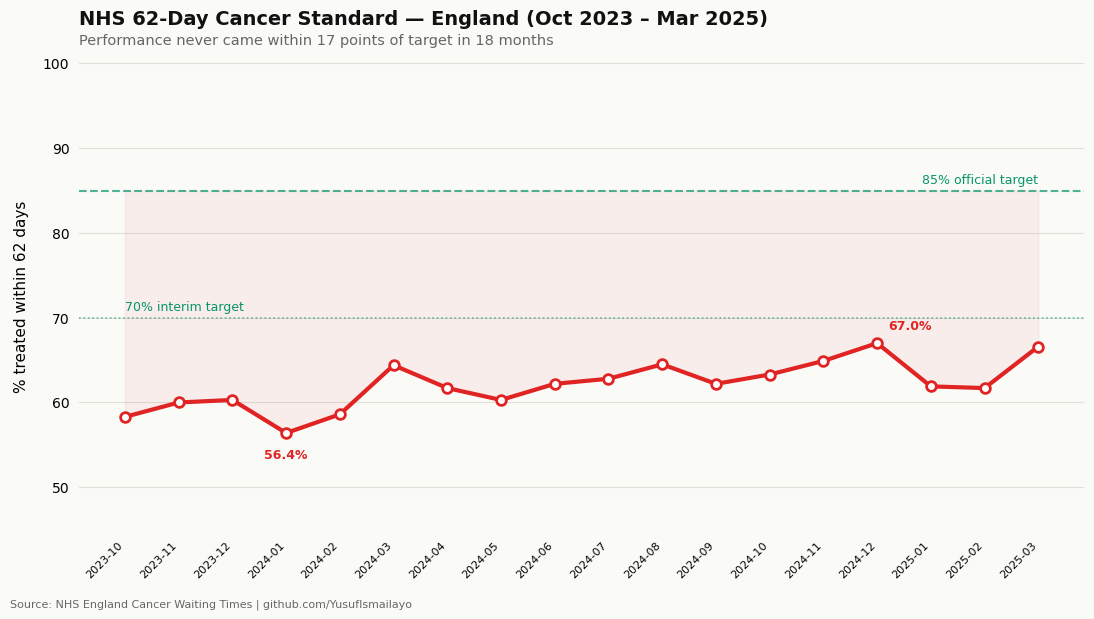

Chart 1 saved: chart1_62d_national_trend.png


In [24]:
# I build my opening chart: the national 62-day compliance line vs both targets.
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(cwt.BG)
cwt.style_axes(ax)

# I plot compliance as a solid red line — this is the failing metric, so red is honest.
x = range(len(national_trend))
ax.plot(x, national_trend["compliance_pct"], color=cwt.RED, linewidth=3, zorder=4,
        marker="o", markersize=7, markerfacecolor="white",
        markeredgecolor=cwt.RED, markeredgewidth=2, label="62-day compliance")

# I draw both target lines as dashed reference lines so the gap is visible.
ax.axhline(85, color=cwt.GREEN, linewidth=1.5, linestyle="--", alpha=0.7, zorder=2)
ax.text(len(x) - 1, 85.8, "85% official target", color=cwt.GREEN, fontsize=9, ha="right")
ax.axhline(70, color=cwt.GREEN, linewidth=1.2, linestyle=":", alpha=0.6, zorder=2)
ax.text(0, 70.8, "70% interim target", color=cwt.GREEN, fontsize=9, ha="left")

# I shade the gap between the line and the 85% target — the visual weight of the failure.
ax.fill_between(x, national_trend["compliance_pct"], 85, alpha=0.06, color=cwt.RED, zorder=1)

# I label the worst and best months so the reader anchors on real figures.
worst_i = national_trend["compliance_pct"].idxmin()
best_i = national_trend["compliance_pct"].idxmax()
worst_pos = national_trend.index.get_loc(worst_i)
best_pos = national_trend.index.get_loc(best_i)
ax.annotate(f"{national_trend.loc[worst_i,'compliance_pct']}%",
            xy=(worst_pos, national_trend.loc[worst_i,'compliance_pct']),
            xytext=(0, -18), textcoords="offset points", ha="center",
            fontsize=9, fontweight="bold", color=cwt.RED)
ax.annotate(f"{national_trend.loc[best_i,'compliance_pct']}%",
            xy=(best_pos, national_trend.loc[best_i,'compliance_pct']),
            xytext=(8, 10), textcoords="offset points", ha="left",
            fontsize=9, fontweight="bold", color=cwt.RED)

# Axes, title, x labels.
ax.set_ylim(45, 100)
ax.set_ylabel("% treated within 62 days", fontsize=11, labelpad=10)
ax.set_xticks(x)
ax.set_xticklabels(national_trend["period_month"], rotation=45, ha="right", fontsize=8)
ax.set_title("NHS 62-Day Cancer Standard — England (Oct 2023 – Mar 2025)",
             fontsize=14, fontweight="bold", color=cwt.INK, pad=28, loc="left")
ax.text(0, 1.04, "Performance never came within 17 points of target in 18 months",
        transform=ax.transAxes, fontsize=10.5, color=cwt.GREY)

cwt.source_note(fig, cwt.SOURCE_LINE)
plt.tight_layout()
plt.savefig(cwt.OUTPUTS_DIR / "chart1_62d_national_trend.png", dpi=180,
            bbox_inches="tight", facecolor=cwt.BG)
plt.show()
print("Chart 1 saved: chart1_62d_national_trend.png")

## Chart 2 — The lottery: worst vs best trusts

This is the image that earns the article's title. I show the 10 worst and 10 best trusts on
the 62-day standard as a horizontal bar chart — worst in red at the top, best in blue at the
bottom. The visual gap between the two blocks IS the lottery: a patient at the top of the
chart has roughly half the chance of timely treatment as one at the bottom.

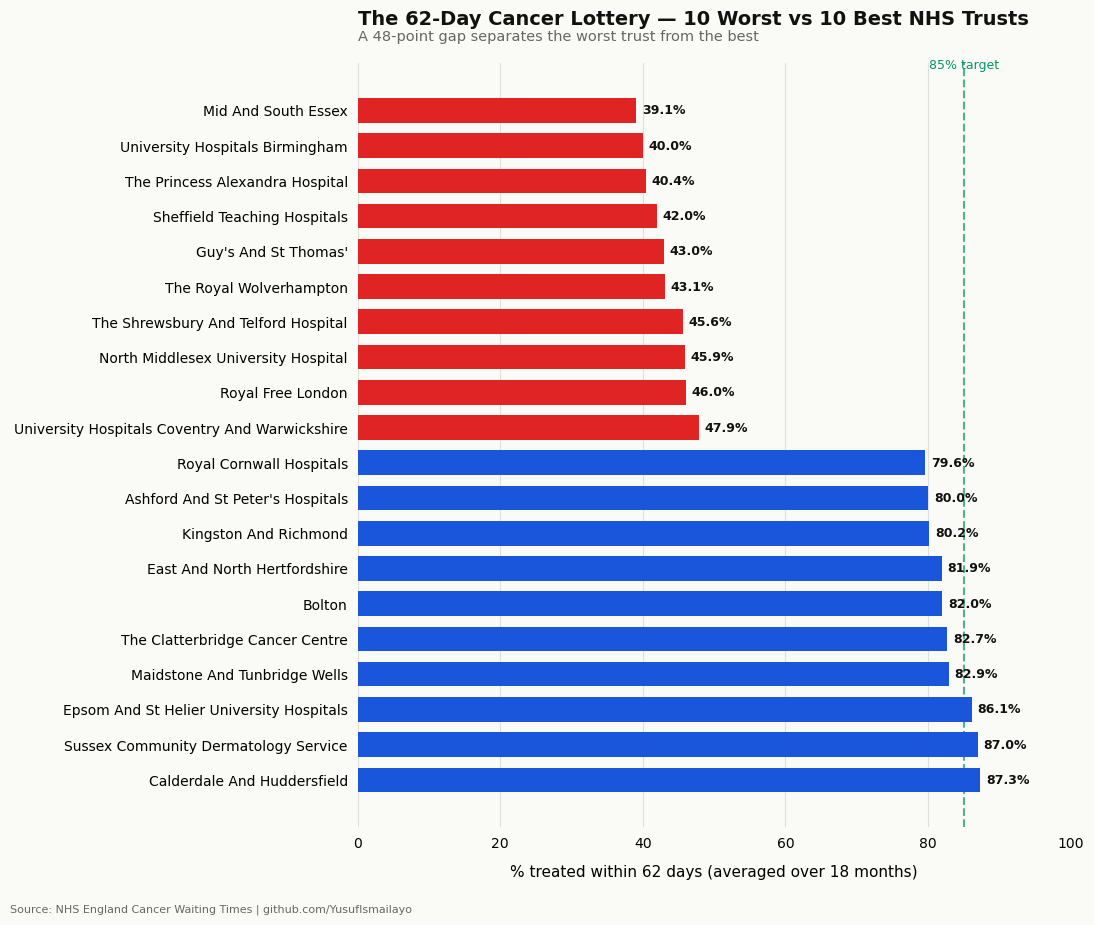

Chart 2 saved: chart2_62d_trust_lottery.png


In [29]:
# I take the 10 worst and 10 best trusts from my ranking for the chart.
worst10 = ranked.head(10).copy()
best10 = ranked.tail(10).copy()
chart_df = pd.concat([worst10, best10]).copy()

# I shorten trust names for readable axis labels (drop the NHS boilerplate suffixes).
def short_name(name):
    for suffix in [" NHS FOUNDATION TRUST", " NHS TRUST", " NHS Foundation Trust", " NHS Trust"]:
        name = name.replace(suffix, "")
    name = name.title()
    # I fix the apostrophe-S quirk that .title() introduces (Guy'S -> Guy's).
    name = name.replace("'S", "'s")
    return name
    

chart_df["label"] = chart_df["Org_Name"].apply(short_name)

# I colour worst trusts red, best trusts blue — the two ends of the lottery.
colors = [cwt.RED] * len(worst10) + [cwt.BLUE] * len(best10)

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor(cwt.BG)
cwt.style_axes(ax)
ax.xaxis.grid(True, color="#E0E0D8", linewidth=0.8, zorder=0)
ax.yaxis.grid(False)

y = range(len(chart_df))
ax.barh(y, chart_df["compliance_pct"], color=colors, height=0.7, zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(chart_df["label"], fontsize=10)
ax.invert_yaxis()  # worst at top

# I label each bar with its compliance figure.
for i, v in enumerate(chart_df["compliance_pct"]):
    ax.text(v + 0.8, i, f"{v}%", va="center", ha="left", fontsize=9,
            fontweight="bold", color=cwt.INK)

# I draw the 85% target line for reference.
ax.axvline(85, color=cwt.GREEN, linewidth=1.5, linestyle="--", alpha=0.7, zorder=2)
ax.text(85, -1.2, "85% target", color=cwt.GREEN, fontsize=9, ha="center")

ax.set_xlim(0, 100)
ax.set_xlabel("% treated within 62 days (averaged over 18 months)", fontsize=11, labelpad=10)
ax.set_title("The 62-Day Cancer Lottery — 10 Worst vs 10 Best NHS Trusts",
             fontsize=14, fontweight="bold", color=cwt.INK, pad=28, loc="left")
ax.text(0, 1.03, "A 48-point gap separates the worst trust from the best",
        transform=ax.transAxes, fontsize=10.5, color=cwt.GREY)

cwt.source_note(fig, cwt.SOURCE_LINE)
plt.tight_layout()
plt.savefig(cwt.OUTPUTS_DIR / "chart2_62d_trust_lottery.png", dpi=180,
            bbox_inches="tight", facecolor=cwt.BG)
plt.show()
print("Chart 2 saved: chart2_62d_trust_lottery.png")

## Chart 3 — Where the most patients actually waited

Compliance rate alone undersells the human cost. A large trust with a middling rate can leave
far more real people waiting than a small trust with a terrible rate. This chart ranks trusts
by the absolute number of patients who breached 62 days over the 18 months — the "real people"
view. I annotate each bar with the trust's compliance rate too, so the reader sees both the
volume and the rate behind it.

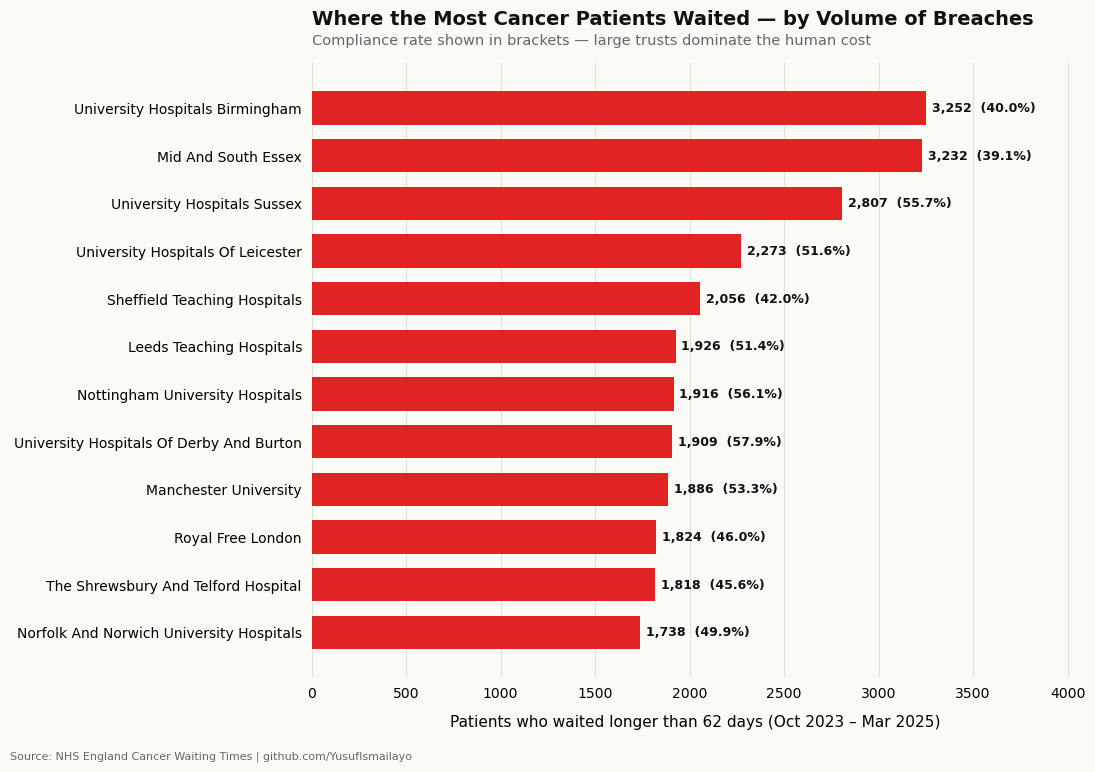

Chart 3 saved: chart3_62d_breach_volume.png


In [32]:
# I rank trusts by absolute breach volume — the number of real patients who waited past 62 days.
by_volume = ranked.sort_values("total_breached", ascending=False).head(12).copy()
by_volume["label"] = by_volume["Org_Name"].apply(short_name)

fig, ax = plt.subplots(figsize=(11, 7.5))
fig.patch.set_facecolor(cwt.BG)
cwt.style_axes(ax)
ax.xaxis.grid(True, color="#E0E0D8", linewidth=0.8, zorder=0)
ax.yaxis.grid(False)

y = range(len(by_volume))
ax.barh(y, by_volume["total_breached"], color=cwt.RED, height=0.7, zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(by_volume["label"], fontsize=10)
ax.invert_yaxis()  # most breaches at top

# I label each bar with the breach count AND the compliance rate in brackets,
# so the reader sees volume and rate together.
for i, row in enumerate(by_volume.itertuples()):
    ax.text(row.total_breached + 30, i,
            f"{row.total_breached:,.0f}  ({row.compliance_pct}%)",
            va="center", ha="left", fontsize=9, fontweight="bold", color=cwt.INK)

ax.set_xlim(0, by_volume["total_breached"].max() * 1.25)
ax.set_xlabel("Patients who waited longer than 62 days (Oct 2023 – Mar 2025)", fontsize=11, labelpad=10)
ax.set_title("Where the Most Cancer Patients Waited — by Volume of Breaches",
             fontsize=14, fontweight="bold", color=cwt.INK, pad=28, loc="left")
ax.text(0, 1.03, "Compliance rate shown in brackets — large trusts dominate the human cost",
        transform=ax.transAxes, fontsize=10.5, color=cwt.GREY)

cwt.source_note(fig, cwt.SOURCE_LINE)
plt.tight_layout()
plt.savefig(cwt.OUTPUTS_DIR / "chart3_62d_breach_volume.png", dpi=180,
            bbox_inches="tight", facecolor=cwt.BG)
plt.show()
print("Chart 3 saved: chart3_62d_breach_volume.png")